## AI-Based 5G Network Congestion Prediction and Load Balancing
### 1. Import Libraries

In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42); torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIGURES = Path("figures"); FIGURES.mkdir(exist_ok=True)
print(f"Device: {device}")

Device: cuda


### 2. Load Dataset

In [12]:
df = pd.read_csv("5g_network_data_processed.csv")
df.columns = (df.columns.str.strip()
              .str.replace(r"[^\w]+", "_", regex=True)
              .str.strip("_"))
for col in df.select_dtypes(include=["bool"]).columns:
    df[col] = df[col].astype(int)
df = df.drop(columns=["Timestamp"], errors="ignore")
print(f"Shape: {df.shape}")
df.head()

Shape: (50000, 25)


,Location,Signal_Strength_dBm,Download_Speed_Mbps,Upload_Speed_Mbps,Latency_ms,Jitter_ms,Network_Type,Device_Model,Carrier,Band,...,Video_Streaming_Quality,VoNR_Enabled,Network_Congestion_Level,Ping_to_Google_ms,Dropped_Connection,Speed_Ratio,Latency_Jitter,Signal_Latency,Load_Index,Stress_Score
0,San Francisco,-108.6,714.94,60.41,10.0,4.09,5G NSA,iPhone 14,AT&T,n78,...,4,0,Medium,27.9,1,11.834795,40.900,-9.872727,6.493333,0.528925
1,San Francisco,-71.5,686.69,148.70,12.3,1.50,4G,Pixel 7,AT&T,n260,...,3,1,Low,22.2,0,4.617956,18.450,-5.375940,2.754423,0.318890
2,Chennai,-67.5,796.34,136.33,19.9,1.22,5G NSA,iPhone 14,Airtel,n78,...,5,0,Medium,75.5,0,5.841267,24.278,-3.229665,3.894565,0.448523
3,New York,-73.3,208.56,68.59,12.2,4.94,4G,Pixel 7,T-Mobile,n41,...,4,0,Medium,87.5,0,3.040676,60.268,-5.553030,2.630000,0.646641
4,Kolkata,-93.2,409.85,137.23,6.3,2.94,5G NSA,Galaxy S23,BSNL,n28,...,1,1,Medium,32.5,1,2.986592,18.522,-12.767123,2.852909,0.439001


### 3. Feature Engineering & Label Setup

In [13]:
df["Speed_Ratio"]    = df["Download_Speed_Mbps"] / (df["Upload_Speed_Mbps"] + 1e-6)
df["Latency_Jitter"] = df["Latency_ms"] * df["Jitter_ms"]
df["Signal_Latency"] = df["Signal_Strength_dBm"] / (df["Latency_ms"] + 1)
df["Load_Index"]     = df["Data_Usage_MB"] / (df["Connected_Duration_min"] + 1)

FEATURES = [
    "Signal_Strength_dBm", "Download_Speed_Mbps", "Upload_Speed_Mbps",
    "Latency_ms", "Jitter_ms", "Ping_to_Google_ms", "Data_Usage_MB",
    "Handover_Count", "Connected_Duration_min",
    "Speed_Ratio", "Latency_Jitter", "Signal_Latency", "Load_Index",
]
LABEL_MAP = {"Low": 0, "Medium": 1, "High": 2}
ID_MAP    = {v: k for k, v in LABEL_MAP.items()}
CLASS_NAMES = ["Low", "Medium", "High"]

X_all = df[FEATURES].copy()
y_all = df["Network_Congestion_Level"].map(LABEL_MAP)
print("Features:", FEATURES)
print("\nClass distribution:")
print(y_all.map(ID_MAP).value_counts())

Features: ['Signal_Strength_dBm', 'Download_Speed_Mbps', 'Upload_Speed_Mbps', 'Latency_ms', 'Jitter_ms', 'Ping_to_Google_ms', 'Data_Usage_MB', 'Handover_Count', 'Connected_Duration_min', 'Speed_Ratio', 'Latency_Jitter', 'Signal_Latency', 'Load_Index']

Class distribution:
Network_Congestion_Level
Medium    38961
Low        9298
High       1741
Name: count, dtype: int64


### 4. Train / Test Split & Scaling

In [14]:
split = int(len(X_all) * 0.8)
X_train_df, X_test_df = X_all.iloc[:split].copy(), X_all.iloc[split:].copy()
y_train_s,  y_test_s  = y_all.iloc[:split].copy(), y_all.iloc[split:].copy()
X_train_orig = X_train_df.reset_index(drop=True)
X_test_orig  = X_test_df.reset_index(drop=True)

scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train_df)
X_test  = scaler.transform(X_test_df)

classes_arr = np.array(sorted(y_train_s.unique()))
cw = compute_class_weight("balanced", classes=classes_arr, y=y_train_s)
class_weights = torch.tensor(cw, dtype=torch.float32, device=device)

X_tr = torch.tensor(X_train, dtype=torch.float32, device=device)
X_te = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_tr = torch.tensor(y_train_s.values, dtype=torch.long, device=device)
y_te = torch.tensor(y_test_s.values,  dtype=torch.long, device=device)

print(f"Train: {len(X_train_orig)}  |  Test: {len(X_test_orig)}")
print("Class weights:", dict(zip(classes_arr.tolist(), cw.tolist())))

Train: 40000  |  Test: 10000
Class weights: {0: 1.801558347970995, 1: 0.4276245456489203, 2: 9.396288466055909}


### 5. TELU Neural Network Definition

In [15]:
class TELU(nn.Module):
    def forward(self, x):
        return x * torch.tanh(torch.exp(torch.clamp(x, max=10.0)))

class Net(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, 128), nn.BatchNorm1d(128), TELU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.BatchNorm1d(64), TELU(), nn.Dropout(0.3),
            nn.Linear(64, 32), TELU(),
            nn.Linear(32, 3),
        )
    def forward(self, x): return self.net(x)

model = Net(X_tr.shape[1]).to(device)
print(model)

Net(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): TELU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): TELU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): TELU()
    (10): Linear(in_features=32, out_features=3, bias=True)
  )
)


### 6. Training (records train AND test metrics)

In [16]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

tr_losses, te_losses = [], []
tr_accs,   te_accs   = [], []

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    model.train()
    out  = model(X_tr)
    loss = criterion(out, y_tr)
    optimizer.zero_grad(); loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        t_out = model(X_tr); v_out = model(X_te)
        t_l = criterion(t_out, y_tr).item(); v_l = criterion(v_out, y_te).item()
        t_a = (torch.argmax(t_out,1) == y_tr).float().mean().item()
        v_a = (torch.argmax(v_out,1) == y_te).float().mean().item()

    tr_losses.append(t_l); te_losses.append(v_l)
    tr_accs.append(t_a);   te_accs.append(v_a)

    if epoch == 1 or epoch % 50 == 0 or epoch == EPOCHS:
        print(f"Ep {epoch:>3}/{EPOCHS} | TrLoss {t_l:.4f} TeLoss {v_l:.4f} | "
              f"TrAcc {t_a:.4f} TeAcc {v_a:.4f}")

torch.save(model.state_dict(), "model.pth")
print("\nModel saved → model.pth")

Ep   1/300 | TrLoss 1.0954 TeLoss 1.0973 | TrAcc 0.7795 TeAcc 0.7781
Ep  50/300 | TrLoss 0.3425 TeLoss 0.3485 | TrAcc 0.6788 TeAcc 0.6854
Ep 100/300 | TrLoss 0.1272 TeLoss 0.1283 | TrAcc 0.8830 TeAcc 0.8860
Ep 150/300 | TrLoss 0.0793 TeLoss 0.0806 | TrAcc 0.9207 TeAcc 0.9222
Ep 200/300 | TrLoss 0.0642 TeLoss 0.0656 | TrAcc 0.9350 TeAcc 0.9373
Ep 250/300 | TrLoss 0.0545 TeLoss 0.0560 | TrAcc 0.9444 TeAcc 0.9461
Ep 300/300 | TrLoss 0.0484 TeLoss 0.0498 | TrAcc 0.9508 TeAcc 0.9526

Model saved → model.pth


### 7. Evaluation

In [17]:
model.eval()
with torch.no_grad():
    predicted = torch.argmax(model(X_te), 1)

y_np = y_te.cpu().numpy()
p_np = predicted.cpu().numpy()

acc = accuracy_score(y_np, p_np)
report_text = classification_report(y_np, p_np, labels=[0,1,2],
                                    target_names=CLASS_NAMES, digits=4, zero_division=0)
report_dict = classification_report(y_np, p_np, labels=[0,1,2],
                                    target_names=CLASS_NAMES, zero_division=0, output_dict=True)
cm = confusion_matrix(y_np, p_np, labels=[0,1,2])

print(f"Final Train Accuracy : {tr_accs[-1]:.4f}")
print(f"Test  Accuracy       : {acc:.4f}")
print(report_text)

Final Train Accuracy : 0.9508
Test  Accuracy       : 0.9526
              precision    recall  f1-score   support

         Low     0.8782    1.0000    0.9352      1897
      Medium     1.0000    0.9391    0.9686      7781
        High     0.6041    1.0000    0.7532       322

    accuracy                         0.9526     10000
   macro avg     0.8275    0.9797    0.8857     10000
weighted avg     0.9642    0.9526    0.9553     10000



### 8. Decision Engine

In [18]:
STRESS_FEAT = ["Latency_ms","Jitter_ms","Ping_to_Google_ms",
               "Download_Speed_Mbps","Upload_Speed_Mbps",
               "Signal_Strength_dBm","Data_Usage_MB","Handover_Count"]
ranges = {f: (X_train_orig[f].min(), X_train_orig[f].max()) for f in STRESS_FEAT}
WEIGHTS = {"Latency_ms":0.20,"Jitter_ms":0.12,"Ping_to_Google_ms":0.13,
           "Download_Speed_Mbps":0.15,"Upload_Speed_Mbps":0.10,
           "Signal_Strength_dBm":0.15,"Data_Usage_MB":0.10,"Handover_Count":0.05}
INV = {"Download_Speed_Mbps","Upload_Speed_Mbps","Signal_Strength_dBm"}

def _norm(v, lo, hi, inv=False):
    if hi == lo: return 0.0
    n = float(np.clip((v-lo)/(hi-lo), 0, 1))
    return 1.0-n if inv else n

def stress(row):
    return sum(WEIGHTS[f]*_norm(row[f],*ranges[f],f in INV) for f in WEIGHTS)

def action(row, pred, s, base):
    lat,jit,sig,dl,hc = row["Latency_ms"],row["Jitter_ms"],row["Signal_Strength_dBm"],row["Download_Speed_Mbps"],row["Handover_Count"]
    if pred==2:
        if lat>15 and s>=0.65: return "Route to low latency path"
        if sig<-95 and s>=0.60: return "Switch to stronger cell"
        if jit>8 or hc>=6: return "Stabilize connection"
        return "Immediate load balancing"
    if pred==1:
        if s>=0.60: return "Immediate load balancing"
        if lat>15: return "Route to low latency path"
        if sig<-95: return "Switch to stronger cell"
        if jit>8 or hc>=6: return "Stabilize connection"
        if s>=0.45 or dl<base: return "Monitor network"
        return "No action"
    if s>=0.55: return "Monitor network"
    if jit>8 and sig<-95: return "Stabilize connection"
    return "No action"

base = X_train_orig["Download_Speed_Mbps"].median()
stresses = [stress(X_test_orig.iloc[i]) for i in range(len(p_np))]
actions  = [action(X_test_orig.iloc[i], int(p_np[i]), stresses[i], base) for i in range(len(p_np))]
action_counts = pd.Series(actions).value_counts()
print(action_counts)

Monitor network              2680
No action                    2579
Route to low latency path    1825
Switch to stronger cell      1643
Immediate load balancing     1273
Name: count, dtype: int64


### 9a. Figure — System Architecture (Section 2)

AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

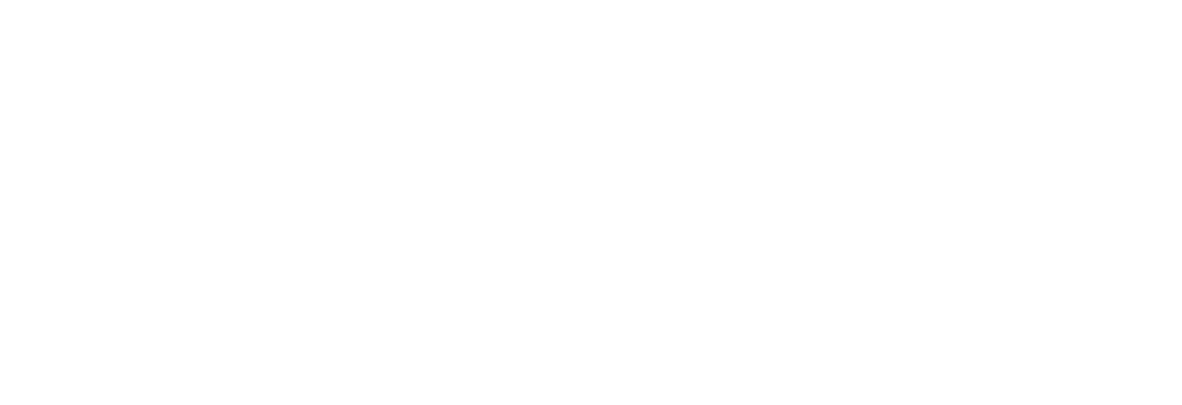

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5)); ax.axis("off")
blocks = [
    ("Raw 5G\nCSV Data", 0.06, "#AED6F1"),
    ("Data Cleaning\n& Feature Eng.", 0.22, "#A9DFBF"),
    ("Train / Test\nSplit 80/20", 0.38, "#A9DFBF"),
    ("TELU Neural\nNetwork", 0.54, "#F9E79F"),
    ("Evaluation\nAccuracy · F1 · CM", 0.70, "#FAD7A0"),
    ("Decision Engine\nLoad Balancing", 0.86, "#F1948A"),
]
for label, xc, color in blocks:
    ax.add_patch(mpatches.FancyBboxPatch((xc-0.075, 0.20), 0.135, 0.60,
        boxstyle="round,pad=0.02", lw=1.8, edgecolor="#444",
        facecolor=color, transform=ax.transAxes, clip_on=False))
    ax.text(xc, 0.50, label, ha="center", va="center",
            fontsize=9.5, fontweight="bold", transform=ax.transAxes)
for i in range(len(blocks)-1):
    ax.annotate("", xy=(blocks[i+1][1]-0.076, 0.50),
                xytext=(blocks[i][1]+0.065, 0.50),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(arrowstyle="->", color="#333", lw=2.0))
ax.text(0.50, 0.93,
    "System Architecture — 5G Network Congestion Prediction & Load Balancing",
    ha="center", fontsize=12, fontweight="bold", transform=ax.transAxes)
plt.tight_layout()
plt.savefig(FIGURES / "fig_architecture.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_architecture.png")

### 9b. Figure — Algorithm Workflow (Section 2)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 14))
ax.set_xlim(0, 10); ax.set_ylim(0, 19); ax.axis("off")
steps = [
    (5, 18.0, "START",                                          "#2ECC71", "oval"),
    (5, 16.2, "Load 5G Telemetry CSV",                          "#AED6F1", "rect"),
    (5, 14.3, "Clean Columns & Encode Booleans",                "#AED6F1", "rect"),
    (5, 12.4, "Feature Engineering\n(Speed Ratio, Load Index…)","#AED6F1", "rect"),
    (5, 10.5, "80/20 Train-Test Split\n(ordered, no shuffle)",  "#A9DFBF", "rect"),
    (5,  8.6, "Min-Max Scaling\n(fit on train only)",           "#A9DFBF", "rect"),
    (5,  6.7, "Train TELU Network\n(300 epochs, AdamW)",        "#F9E79F", "rect"),
    (5,  4.8, "Evaluate Model\n(Accuracy, F1, CM)",             "#FAD7A0", "rect"),
    (5,  2.9, "Decision Engine\n(Stress Score → Action)",       "#F1948A", "rect"),
    (5,  1.2, "Save All Figures & Metrics",                     "#D2B4DE", "rect"),
    (5,  0.0, "END",                                            "#E74C3C", "oval"),
]
for x, y, text, color, shape in steps:
    if shape == "oval":
        ax.add_patch(mpatches.Ellipse((x,y), 3.6, 0.85, facecolor=color, edgecolor="#444", lw=1.5, zorder=3))
    else:
        ax.add_patch(mpatches.FancyBboxPatch((x-2.1, y-0.55), 4.2, 1.1,
            boxstyle="round,pad=0.1", facecolor=color, edgecolor="#444", lw=1.2, zorder=3))
    ax.text(x, y, text, ha="center", va="center", fontsize=8.5, fontweight="bold", zorder=4)
for i in range(len(steps)-1):
    ax.annotate("", xy=(5, steps[i+1][1]+0.43), xytext=(5, steps[i][1]-0.43),
                arrowprops=dict(arrowstyle="->", color="#333", lw=1.5))
ax.set_title("Algorithm Workflow", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "fig_workflow.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_workflow.png")

### 10a. Figure — Class Distribution (Section 4)

In [ ]:
counts = y_all.map(ID_MAP).value_counts().reindex(CLASS_NAMES)
colors = ["#2ecc71","#f39c12","#e74c3c"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bars = axes[0].bar(CLASS_NAMES, counts.values, color=colors, edgecolor="black")
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 str(cnt), ha="center", fontweight="bold")
axes[0].set_title("Class Count"); axes[0].set_xlabel("Congestion Level")
axes[0].set_ylabel("Samples"); axes[0].grid(axis="y", alpha=0.3)
axes[1].pie(counts.values, labels=CLASS_NAMES, colors=colors,
            autopct="%1.1f%%", startangle=90, pctdistance=0.80)
axes[1].set_title("Class Proportion")
fig.suptitle("Dataset Class Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "fig_class_distribution.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_class_distribution.png")

### 10b. Figure — Learning Curves (Section 4)

In [ ]:
ep = range(1, EPOCHS+1)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(ep, tr_losses, color="#2980b9", label="Train Loss")
axes[0,0].plot(ep, te_losses, color="#e74c3c", linestyle="--", label="Test Loss")
axes[0,0].set_title("Loss Curve (Train vs Test)"); axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, tr_losses, color="#2980b9")
axes[0,1].set_title("Training Loss"); axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Loss"); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(ep, tr_accs, color="#27ae60", label="Train Acc")
axes[1,0].plot(ep, te_accs, color="#8e44ad", linestyle="--", label="Test Acc")
axes[1,0].set_title("Accuracy Curve (Train vs Test)"); axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("Accuracy"); axes[1,0].set_ylim(0,1.05)
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep, te_accs, color="#8e44ad")
axes[1,1].set_title("Test Accuracy"); axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("Accuracy"); axes[1,1].set_ylim(0,1.05)
axes[1,1].axhline(te_accs[-1], color="red", linestyle=":", lw=1.2)
axes[1,1].text(EPOCHS*0.6, te_accs[-1]+0.02, f"Final: {te_accs[-1]:.4f}", color="red", fontsize=9)
axes[1,1].grid(alpha=0.3)

fig.suptitle("Neural Network Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "fig_learning_curves.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_learning_curves.png")

### 10c. Figure — Confusion Matrix (Section 4)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues"); fig.colorbar(im, ax=ax)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES, fontsize=11); ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=12); ax.set_ylabel("Actual Label", fontsize=12)
ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold")
for r in range(3):
    for c in range(3):
        ax.text(c, r, str(int(cm[r,c])), ha="center", va="center", fontsize=14,
                fontweight="bold", color="white" if cm[r,c] > cm.max()/2 else "black")
plt.tight_layout()
plt.savefig(FIGURES / "fig_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_confusion_matrix.png")

### 10d. Figure — Per-Class Metrics (Section 4)

In [ ]:
prec = [report_dict[c]["precision"] for c in CLASS_NAMES]
rec  = [report_dict[c]["recall"]    for c in CLASS_NAMES]
f1   = [report_dict[c]["f1-score"]  for c in CLASS_NAMES]
x, w = np.arange(3), 0.25
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.bar(x-w, prec, w, label="Precision", color="#3498db", edgecolor="black")
br = ax.bar(x,   rec,  w, label="Recall",    color="#2ecc71", edgecolor="black")
bf = ax.bar(x+w, f1,   w, label="F1-Score",  color="#e74c3c", edgecolor="black")
for bars in [bp, br, bf]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0,1.20); ax.set_xlabel("Congestion Level"); ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics — Precision / Recall / F1", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig_per_class_metrics.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_per_class_metrics.png")

### 10e. Figure — Prediction Distribution (Section 4)

In [ ]:
counts_pred = [np.sum(p_np==i) for i in range(3)]
colors = ["#2ecc71","#f39c12","#e74c3c"]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES, counts_pred, color=colors, edgecolor="black")
for bar, cnt in zip(bars, counts_pred):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            str(cnt), ha="center", fontweight="bold")
ax.set_title("Prediction Distribution — Test Set", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Congestion Level"); ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig_prediction_distribution.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_prediction_distribution.png")

### 10f. Figure — Feature Importance (Section 4)

In [ ]:
weights_np  = model.net[0].weight.detach().cpu().numpy()
importance  = np.mean(np.abs(weights_np), axis=0)
idx = np.argsort(importance)
feats  = [FEATURES[i] for i in idx]
scores = importance[idx]
cmap_vals = plt.cm.RdYlGn(scores/scores.max())
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(feats, scores, color=cmap_vals, edgecolor="black")
for bar, s in zip(bars, scores):
    ax.text(bar.get_width()+0.0003, bar.get_y()+bar.get_height()/2,
            f"{s:.4f}", va="center", fontsize=8)
ax.set_xlabel("Mean |Weight| — First Layer"); ax.set_ylabel("Feature")
ax.set_title("Feature Importance Proxy", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_feature_importance.png")

### 10g. Figure — Stress Score Distribution (Section 4)

In [ ]:
arr = np.array(stresses)
colors_cls = {0:"#2ecc71", 1:"#f39c12", 2:"#e74c3c"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(arr, bins=30, color="#5dade2", edgecolor="black")
axes[0].axvline(arr.mean(), color="red", linestyle="--", label=f"Mean={arr.mean():.3f}")
axes[0].axvline(np.median(arr), color="orange", linestyle=":", label=f"Median={np.median(arr):.3f}")
axes[0].set_title("Overall Stress Score Distribution")
axes[0].set_xlabel("Stress Score"); axes[0].set_ylabel("Count")
axes[0].legend(); axes[0].grid(alpha=0.3)
for cls_id, cls_name in ID_MAP.items():
    mask = p_np == cls_id
    if mask.sum() > 0:
        axes[1].hist(arr[mask], bins=20, alpha=0.65, label=cls_name,
                     color=colors_cls[cls_id], edgecolor="black")
axes[1].set_title("Stress Score by Predicted Class")
axes[1].set_xlabel("Stress Score"); axes[1].set_ylabel("Count")
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.suptitle("Network Stress Score Analysis", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "fig_stress_distribution.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_stress_distribution.png")

### 10h. Figure — Decision Engine Actions (Section 4)

In [ ]:
palette = {
    "No action":"#2ecc71","Monitor network":"#f39c12",
    "Immediate load balancing":"#e67e22","Route to low latency path":"#3498db",
    "Switch to stronger cell":"#9b59b6","Stabilize connection":"#e74c3c",
}
ac_colors = [palette.get(a,"#95a5a6") for a in action_counts.index]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].barh(action_counts.index, action_counts.values,
                    color=ac_colors, edgecolor="black")
for bar, cnt in zip(bars, action_counts.values):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 str(cnt), va="center", fontweight="bold")
axes[0].set_title("Action Count (Test Set)"); axes[0].set_xlabel("Samples")
axes[0].grid(axis="x", alpha=0.3)
axes[1].pie(action_counts.values, labels=action_counts.index,
            colors=ac_colors, autopct="%1.1f%%", startangle=90, pctdistance=0.80)
axes[1].set_title("Action Distribution (%)")
fig.suptitle("Decision Engine — Recommended Network Actions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "fig_decision_actions.png", dpi=200, bbox_inches="tight")
plt.show(); print("Saved fig_decision_actions.png")

### 11. Summary

In [ ]:
print("=" * 55)
print("PROJECT SUMMARY")
print("=" * 55)
print(f"  Final Train Accuracy : {tr_accs[-1]:.4f}")
print(f"  Final Test  Accuracy : {acc:.4f}")
print(f"  Features used        : {len(FEATURES)}")
print(f"  Training epochs      : {EPOCHS}")
print()
print("Figures saved to ./figures/:")
figs = [
    ("fig_architecture.png",        "Section 2: System Architecture"),
    ("fig_workflow.png",            "Section 2: Algorithm Workflow"),
    ("fig_class_distribution.png",  "Section 4: Dataset Balance"),
    ("fig_learning_curves.png",     "Section 4: Train/Test Loss & Accuracy"),
    ("fig_confusion_matrix.png",    "Section 4: Confusion Matrix"),
    ("fig_per_class_metrics.png",   "Section 4: Precision/Recall/F1"),
    ("fig_prediction_distribution.png","Section 4: Prediction Distribution"),
    ("fig_feature_importance.png",  "Section 4: Feature Importance"),
    ("fig_stress_distribution.png", "Section 4: Stress Score Analysis"),
    ("fig_decision_actions.png",    "Section 4: Decision Engine Actions"),
]
for fname, note in figs:
    print(f"  {fname:<38} {note}")